In [2]:
import numpy as np
import pandas as pd

In [ ]:
# Load data efficiently
df = pd.read_csv("terrestrial_ebird_count_habitat_no_year.csv")
#df = df.drop(columns=['year'])  # Drop year column if present
df_o = pd.read_csv("terrestrial_ebird_occurance_habitat_no_year.csv", dtype='str')
#df_o = df_o.drop(columns=['year'])  # Drop year column if present
# Store column names for later use
all_columns = df.columns.tolist()
feature_names = all_columns[3:34]  # Features are columns 3-34
label_names = all_columns[34:438]  # Labels are columns 34-438

# Convert to numpy for processing
data = df.to_numpy()
data_o = df_o.to_numpy()
# Remove rows with all zeros in labels
count_label = data[:, 34:438]

binary_label = data_o[:, 34:438]
non_zero_idx = np.where(np.sum(binary_label, axis=1) != 0)[0]

# Extract features and labels with non-zero rows
count_label = data[non_zero_idx, 34:438]
loc = data[non_zero_idx, 1:3]  # Location data
feat = data[non_zero_idx, 3:34]
binary_label = data_o[non_zero_idx, 34:438]
# Remove columns with all zeros in labels
binary_label = binary_label.astype(np.float32)
non_zero_col_idx = np.where(np.sum(binary_label, axis=0) >= 10)[0]
label = count_label[:, non_zero_col_idx]

# Update label names to match the filtered columns
filtered_label_names = [label_names[i] for i in non_zero_col_idx]

feat = feat.astype(np.float32)
label = label.astype(np.float32)
np.savez_compressed("ebird_data0718.npz",feat=feat, count_label=label, 
                   feature_names=feature_names, label_names=filtered_label_names)

print("Total number of rows:", len(data))
print("Number of rows with non-zero labels:", len(non_zero_idx))
print(f"Removed {len(data) - len(non_zero_idx)} rows with all zeros.")
print(f"Total number of species columns: {len(label_names)}")
print(f"Number of species columns with non-zero counts: {len(non_zero_col_idx)}")
print(f"Removed {len(label_names) - len(non_zero_col_idx)} species columns with all zeros.")

Total number of rows: 115532
Number of rows with non-zero labels: 115532
Removed 0 rows with all zeros.
Total number of species columns: 404
Number of species columns with non-zero counts: 350
Removed 54 species columns with all zeros.


In [5]:
df_o.iloc[:,3:34]

,protocol_type,day_of_year,time_observations_started,duration_minutes,effort_distance_km,number_observers,barren,forest,fresh_marsh,fresh_woody_wetland,...,northness_median,northness_sd,eastness_median,eastness_sd,slopeness_median,slopeness_sd,t_mean,trange_mean,poc_mean,chl_mean
0,0,71,15.9666666666667,5,0.0,1,0.0028981854838709,0.3908770161290322,0.0056703629032258,0.1422631048387097,...,-0.0661078261149807,0.1087606398479751,0.0402026108117306,0.1385474520253314,0.518331946586761,0.1692791391597213,0.3885473238440051,0.7945957455371562,0.5473598338312171,0.5778080100952985
1,0,277,16.0166666666667,60,0.0,1,0.0028981854838709,0.3908770161290322,0.0056703629032258,0.1422631048387097,...,-0.0661078261149807,0.1087606398479751,0.0402026108117306,0.1385474520253314,0.518331946586761,0.1692791391597213,0.3885473238440051,0.7945957455371562,0.5473598338312171,0.5778080100952985
2,1,280,7.83333333333333,74,1.502,1,0.1780493951612903,0.0007560483870967,0.0008820564516129,0.0063004032258064,...,0.0041377137235379,0.1815718980494907,0.027010207400464,0.0583760369002085,0.262160227027152,0.1833980633868931,0.573608723521675,0.4977322591921357,0.6011905778210268,0.0085343273345269
3,1,277,11.0,240,1.609,2,0.0001261511290526,0.0,0.0001261511290526,0.0,...,0.0015526935163312,0.0037570820093604,-3.941280522139385e-06,0.0158675396261355,0.0183569940136787,0.0309509467745548,0.3219442081051563,0.7272590140808891,0.6176181311991698,0.0
4,1,277,16.0,60,0.805,1,0.0001259921884843,0.0,0.0002519843769686,0.0,...,0.0032127839517242,0.0096097475376639,0.0008845491633239,0.0192291837419904,0.033990034154065,0.0344269630067061,0.3219442081051563,0.7272590140808891,0.6015825644253657,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115527,0,278,16.75,80,0.0,1,0.000630755645263,0.3585215087675035,0.0010092090324208,0.0425129304907278,...,-0.1613652736201529,0.4674806346558328,0.0580902182913197,0.1715288009529887,1.0456903820218724,0.2853071016588029,0.1460482202385074,0.8779691742441267,0.4331895261842243,0.6684930848376966
115528,1,279,14.5,90,1.609,2,0.1602370146243066,0.0249621785173978,0.0001260716086737,0.0158850226928895,...,-0.0648136818504574,0.2289496872888166,-0.0643501694064337,0.088123387484184,0.2366023308835251,0.2380371933037328,0.3008946579093494,0.6917633715175022,0.5924627496047279,0.0106281081691395
115529,1,281,8.08333333333333,55,1.609,1,0.1602370146243066,0.0249621785173978,0.0001260716086737,0.0158850226928895,...,-0.0648136818504574,0.2289496872888166,-0.0643501694064337,0.088123387484184,0.2366023308835251,0.2380371933037328,0.3008946579093494,0.6917633715175022,0.5924627496047279,0.0106281081691395
115530,1,282,7.5,62,4.023,1,0.1602370146243066,0.0249621785173978,0.0001260716086737,0.0158850226928895,...,-0.0648136818504574,0.2289496872888166,-0.0643501694064337,0.088123387484184,0.2366023308835251,0.2380371933037328,0.3008946579093494,0.6917633715175022,0.5924627496047279,0.0106281081691395


In [20]:
habitat = pd.read_csv("habitat.csv")
habitat

,id,longitude,latitude,agriculture,forest,fresh_woody_wetland,grassland,pasture,shrub,urban,...,northness_median,northness_sd,eastness_median,eastness_sd,slopeness_median,slopeness_sd,t_mean,trange_mean,poc_mean,chl_mean
0,1,-90.741403,31.250508,0.000126,0.830732,0.098792,0.005034,0.026303,0.038132,0.000126,...,-0.123021,0.252100,-0.133841,0.336319,0.988993,0.196292,0.018325,0.861996,0.621959,0.828482
1,2,-90.711354,31.262355,0.000000,0.483696,0.143648,0.067229,0.145285,0.132066,0.000000,...,-0.022202,0.149107,0.087380,0.286207,0.748420,0.189879,0.018574,0.868938,0.675814,0.800176
2,3,-90.741756,31.216798,0.000000,0.673431,0.096042,0.021931,0.036804,0.144190,0.001512,...,-0.096686,0.246243,0.073307,0.310156,0.817156,0.193318,0.025112,0.866896,0.577217,0.807298
3,4,-90.711710,31.228642,0.000126,0.551833,0.140320,0.046857,0.116639,0.123693,0.000126,...,-0.207571,0.306762,-0.088071,0.333790,0.924225,0.199978,0.025550,0.869451,0.660895,0.793092
4,5,-90.681662,31.240476,0.000000,0.596265,0.091219,0.080621,0.101691,0.095887,0.000252,...,-0.137074,0.196224,0.224000,0.290197,0.902748,0.251762,0.020166,0.873475,0.700971,0.787501
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5861,5862,-85.048892,30.015759,0.002015,0.343746,0.642650,0.000378,0.000000,0.003401,0.000000,...,-0.032651,0.136388,-0.032045,0.099685,0.418185,0.090959,0.560826,0.672992,0.769189,0.580295
5862,5863,-85.018489,30.026002,0.000000,0.679697,0.211602,0.001765,0.000000,0.052585,0.000126,...,-0.018897,0.096137,0.035204,0.124248,0.511171,0.104689,0.558285,0.676259,0.554383,0.204792
5863,5864,-84.988076,30.036238,0.000000,0.462401,0.371961,0.009069,0.000000,0.037662,0.002015,...,-0.000218,0.121056,-0.023815,0.070257,0.441907,0.092879,0.562176,0.690886,0.427358,0.341148
5864,5865,-85.020372,29.992604,0.000000,0.331275,0.579385,0.000882,0.000000,0.003528,0.000504,...,-0.005998,0.101249,0.009438,0.107838,0.369798,0.082318,0.571472,0.656874,0.623389,0.417386


In [27]:
habitat = pd.read_csv("habitat.csv")
habitat

,id,longitude,latitude,agriculture,forest,fresh_woody_wetland,grassland,pasture,shrub,urban,...,northness_median,northness_sd,eastness_median,eastness_sd,slopeness_median,slopeness_sd,t_mean,trange_mean,poc_mean,chl_mean
0,1,-90.741403,31.250508,0.000126,0.830732,0.098792,0.005034,0.026303,0.038132,0.000126,...,-0.123021,0.252100,-0.133841,0.336319,0.988993,0.196292,0.018325,0.861996,0.621959,0.828482
1,2,-90.711354,31.262355,0.000000,0.483696,0.143648,0.067229,0.145285,0.132066,0.000000,...,-0.022202,0.149107,0.087380,0.286207,0.748420,0.189879,0.018574,0.868938,0.675814,0.800176
2,3,-90.741756,31.216798,0.000000,0.673431,0.096042,0.021931,0.036804,0.144190,0.001512,...,-0.096686,0.246243,0.073307,0.310156,0.817156,0.193318,0.025112,0.866896,0.577217,0.807298
3,4,-90.711710,31.228642,0.000126,0.551833,0.140320,0.046857,0.116639,0.123693,0.000126,...,-0.207571,0.306762,-0.088071,0.333790,0.924225,0.199978,0.025550,0.869451,0.660895,0.793092
4,5,-90.681662,31.240476,0.000000,0.596265,0.091219,0.080621,0.101691,0.095887,0.000252,...,-0.137074,0.196224,0.224000,0.290197,0.902748,0.251762,0.020166,0.873475,0.700971,0.787501
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5861,5862,-85.048892,30.015759,0.002015,0.343746,0.642650,0.000378,0.000000,0.003401,0.000000,...,-0.032651,0.136388,-0.032045,0.099685,0.418185,0.090959,0.560826,0.672992,0.769189,0.580295
5862,5863,-85.018489,30.026002,0.000000,0.679697,0.211602,0.001765,0.000000,0.052585,0.000126,...,-0.018897,0.096137,0.035204,0.124248,0.511171,0.104689,0.558285,0.676259,0.554383,0.204792
5863,5864,-84.988076,30.036238,0.000000,0.462401,0.371961,0.009069,0.000000,0.037662,0.002015,...,-0.000218,0.121056,-0.023815,0.070257,0.441907,0.092879,0.562176,0.690886,0.427358,0.341148
5864,5865,-85.020372,29.992604,0.000000,0.331275,0.579385,0.000882,0.000000,0.003528,0.000504,...,-0.005998,0.101249,0.009438,0.107838,0.369798,0.082318,0.571472,0.656874,0.623389,0.417386


In [7]:
# Load data efficiently
habitat = pd.read_csv("habitat.csv")
df_o = pd.read_csv("terrestrial_ebird_occurance_habitat_no_year.csv", dtype='str')
#df_o = df_o.drop(columns=['year'])  # Drop year column if present
# Store column names for later use
feat_columns = habitat.columns.tolist()
all_columns = df_o.columns.tolist()
feature_names = all_columns[3:34]  # Features are columns 1-33
label_names = all_columns[34:438]  # Labels are columns 34-437

# Convert to numpy for processing
data = habitat.to_numpy()
data_o = df_o.to_numpy()
# Remove rows with all zeros in labels

binary_label = data_o[:, 34:438]
count_label = np.zeros((data.shape[0], 350), dtype=np.float32)  # Initialize feat with zeros

# Extract features and labels with non-zero rows


feat = np.zeros((data.shape[0], 31), dtype=np.float32)  # Initialize feat with zeros
# Add additional features
feat[0] = 0
feat[1] = 258
feat[2] = 10.0
feat[3] = 60
feat[4] = 1.0
feat[5] = 1.0

 # Extract features from the habitat data
feat[:, 6:] = data[:,3:]
#feat[:, :2] = data[:,1:3] # Add a constant feature
binary_label = data_o[:, 34:438]
# Remove columns with all zeros in labels
binary_label = binary_label.astype(np.float32)
non_zero_col_idx = np.where(np.sum(binary_label, axis=0) >= 10)[0]


# Update label names to match the filtered columns
filtered_label_names = [label_names[i] for i in non_zero_col_idx]
loc = data[:, 1:3]  # Location data
feat = feat.astype(np.float32)
label = count_label.astype(np.float32)
np.savez_compressed("ebird_data_esrd0718.npz", feat=feat, count_label=label, 
                   feature_names=feature_names, label_names=filtered_label_names)

np.savez_compressed("loc0718.npz", loc=loc)
print("Total number of rows:", len(data))


print(f"Total number of species columns: {len(label_names)}")
print(f"Number of species columns with non-zero counts: {len(non_zero_col_idx)}")
print(f"Removed {len(label_names) - len(non_zero_col_idx)} species columns with all zeros.")

Total number of rows: 5866
Total number of species columns: 404
Number of species columns with non-zero counts: 350
Removed 54 species columns with all zeros.


In [4]:
# Load data efficiently
habitat = pd.read_csv("pred_pland_elev_poc_chl_t_trangeintHigh_3year_mp_marshmigration.csv")
df_o = pd.read_csv("terrestrial_ebird_occurance_habitat_no_year.csv", dtype='str')
#df_o = df_o.drop(columns=['year'])  # Drop year column if present
# Store column names for later use
feat_columns = habitat.columns.tolist()
all_columns = df_o.columns.tolist()
feature_names = all_columns[3:34]  # Features are columns 1-33
label_names = all_columns[34:438]  # Labels are columns 34-437

# Convert to numpy for processing
data = habitat.to_numpy()
data_o = df_o.to_numpy()
# Remove rows with all zeros in labels

binary_label = data_o[:, 34:438]
count_label = np.zeros((data.shape[0], 350), dtype=np.float32)  # Initialize feat with zeros

# Extract features and labels with non-zero rows


feat = np.zeros((data.shape[0], 31), dtype=np.float32)  # Initialize feat with zeros
# Add additional features
feat[0] = 0
feat[1] = 258
feat[2] = 10.0
feat[3] = 60
feat[4] = 1.0
feat[5] = 1.0

 # Extract features from the habitat data
feat[:, 6:] = data[:,3:]
#feat[:, :2] = data[:,1:3] # Add a constant feature
binary_label = data_o[:, 34:438]
# Remove columns with all zeros in labels
binary_label = binary_label.astype(np.float32)
non_zero_col_idx = np.where(np.sum(binary_label, axis=0) >= 10)[0]


# Update label names to match the filtered columns
filtered_label_names = [label_names[i] for i in non_zero_col_idx]
loc = data[:, 1:3]  # Location data
feat = feat.astype(np.float32)
label = count_label.astype(np.float32)
np.savez_compressed("ebird_data_esrd_inthigh.npz", feat=feat, count_label=label, 
                   feature_names=feature_names, label_names=filtered_label_names)

#np.savez_compressed("loc0718.npz", loc=loc)
print("Total number of rows:", len(data))


print(f"Total number of species columns: {len(label_names)}")
print(f"Number of species columns with non-zero counts: {len(non_zero_col_idx)}")
print(f"Removed {len(label_names) - len(non_zero_col_idx)} species columns with all zeros.")

Total number of rows: 5866
Total number of species columns: 404
Number of species columns with non-zero counts: 350
Removed 54 species columns with all zeros.


In [8]:
data[:,3:]

array([[1.25849484e-04, 8.30732444e-01, 9.87918450e-02, ...,
        8.61995890e-01, 6.21958646e-01, 8.28482478e-01],
       [0.00000000e+00, 4.83696336e-01, 1.43648496e-01, ...,
        8.68938167e-01, 6.75813591e-01, 8.00176040e-01],
       [0.00000000e+00, 6.73430804e-01, 9.60423494e-02, ...,
        8.66896211e-01, 5.77217294e-01, 8.07298491e-01],
       ...,
       [0.00000000e+00, 4.62400806e-01, 3.71961204e-01, ...,
        6.90885516e-01, 4.27357994e-01, 3.41147602e-01],
       [0.00000000e+00, 3.31275202e-01, 5.79385081e-01, ...,
        6.56873833e-01, 6.23389064e-01, 4.17386254e-01],
       [0.00000000e+00, 6.05163728e-01, 2.48110831e-01, ...,
        6.67867128e-01, 5.07990866e-01, 4.70706120e-01]])

In [46]:
count_metrics = pd.read_csv("count_metrics.csv")
low_rmse_label = count_metrics.loc[count_metrics["RMSE"] < 1, "Label"]
low_rmse_label

0              Acadian Flycatcher
1                Alder Flycatcher
2             Allen's Hummingbird
4                American Bittern
7          American Golden-Plover
                  ...            
343          Yellow-billed Cuckoo
344          Yellow-breasted Chat
345    Yellow-crowned Night Heron
346       Yellow-headed Blackbird
349       Yellow-throated Warbler
Name: Label, Length: 206, dtype: object

In [56]:
# Load data efficiently
df = pd.read_csv("terrestrial_ebird_count_habitat_no_year.csv")
df_o = pd.read_csv("terrestrial_ebird_occurance_habitat_no_year.csv", dtype='str')
# Store column names for later use
all_columns = df.columns.tolist()
feature_names = all_columns[1:34]  # Features are columns 1-33
label_names = all_columns[34:438]  # Labels are columns 34-437

# Convert to numpy for processing
data = df.to_numpy()
data_o = df_o.to_numpy()
# Remove rows with all zeros in labels
count_label = data[:, 34:438]
binary_label = data_o[:, 34:438]
non_zero_idx = np.where(np.sum(binary_label, axis=1) != 0)[0]

# Extract features and labels with non-zero rows
count_label = data[non_zero_idx, 34:438]
feat = data[non_zero_idx, 1:34]
binary_label = data_o[non_zero_idx, 34:438]
# Remove columns with all zeros in labels
binary_label = binary_label.astype(np.float32)
non_zero_col_idx = np.where(np.sum(binary_label, axis=0) >= 10)[0]
label = count_label[:, non_zero_col_idx]

# 'label_names' should be a list of column names corresponding to columns in 'label'
label_names = count_metrics["Label"].tolist()

# Get indices for the low RMSE labels
low_rmse_indices = [label_names.index(name) for name in low_rmse_label]

# Use them to slice the array
filtered_label = label[:, low_rmse_indices]

# Update label names to match the filtered columns
filtered_label_names = [label_names[i] for i in low_rmse_indices]

feat = feat.astype(np.float32)
label = label.astype(np.float32)
np.savez_compressed("ebird_data1.npz", feat=feat, count_label=filtered_label, 
                   feature_names=feature_names, label_names=filtered_label_names)

print("Total number of rows:", len(data))
print("Number of rows with non-zero labels:", len(non_zero_idx))
print(f"Removed {len(data) - len(non_zero_idx)} rows with all zeros.")
print(f"Total number of species columns: {len(filtered_label_names)}")
print(f"Number of species columns with non-zero counts: {len(non_zero_col_idx)}")
print(f"Removed {len(low_rmse_label)} species columns with satisfying rsme.")
print(f"Removed {len(label_names) - len(non_zero_col_idx)} species columns with all zeros.")

Total number of rows: 115532
Number of rows with non-zero labels: 115532
Removed 0 rows with all zeros.
Total number of species columns: 206
Number of species columns with non-zero counts: 350
Removed 206 species columns with satisfying rsme.
Removed 0 species columns with all zeros.


In [57]:
# Load the saved compressed data
data = np.load("ebird_data1.npz", allow_pickle=True)
feat = data['feat']
print(data)
label = data['count_label']
feature_names = data['feature_names']
label_names = data['label_names']

print(f"Features shape: {feat.shape}, {feat.dtype}")
print(f"Labels shape: {label.shape}, {label.dtype}")

NpzFile 'ebird_data1.npz' with keys: feat, count_label, feature_names, label_names
Features shape: (115532, 33), float32
Labels shape: (115532, 206), object


## Feature Analysis

Let's analyze the feature columns (columns 1-33 from the original dataset). We'll summarize the zero/non-zero counts and visualize their distributions.

In [13]:
# Summarize features
feat_summary = {}

for i in range(feat.shape[1]):
    col = feat[:, i]
    col_name = feature_names[i]
    zero_count = np.sum(col == 0)
    non_zero_count = len(col) - zero_count
    
    feat_summary[col_name] = {
        'zero_count': zero_count,
        'non_zero_count': non_zero_count,
        'zero_percentage': zero_count / len(col) * 100,
        'min': np.min(col),
        'max': np.max(col),
        'mean': np.mean(col),
        'median': np.median(col)
    }

# Convert to DataFrame for better visualization
feat_df = pd.DataFrame(feat_summary).T
feat_df

,zero_count,non_zero_count,zero_percentage,min,max,mean,median
protocol_type,51006.0,64526.0,44.148807,0.000000e+00,1.000000,0.558512,1.000000
day_of_year,0.0,115532.0,0.000000,1.000000e+00,366.000000,169.294083,145.000000
time_observations_started,8.0,115524.0,0.006924,0.000000e+00,23.983334,11.212766,10.500000
duration_minutes,0.0,115532.0,0.000000,1.000000e+00,300.000000,58.064156,42.000000
effort_distance_km,51032.0,64500.0,44.171312,0.000000e+00,5.000000,0.928027,0.322000
number_observers,0.0,115532.0,0.000000,1.000000e+00,10.000000,1.301362,1.000000
barren,9026.0,106506.0,7.812554,0.000000e+00,0.286074,0.021142,0.004288
forest,14959.0,100573.0,12.947928,0.000000e+00,0.891589,0.110622,0.050183
fresh_marsh,11292.0,104240.0,9.773915,0.000000e+00,0.850680,0.018913,0.003276
fresh_woody_wetland,9395.0,106137.0,8.131946,0.000000e+00,0.999748,0.107556,0.055370


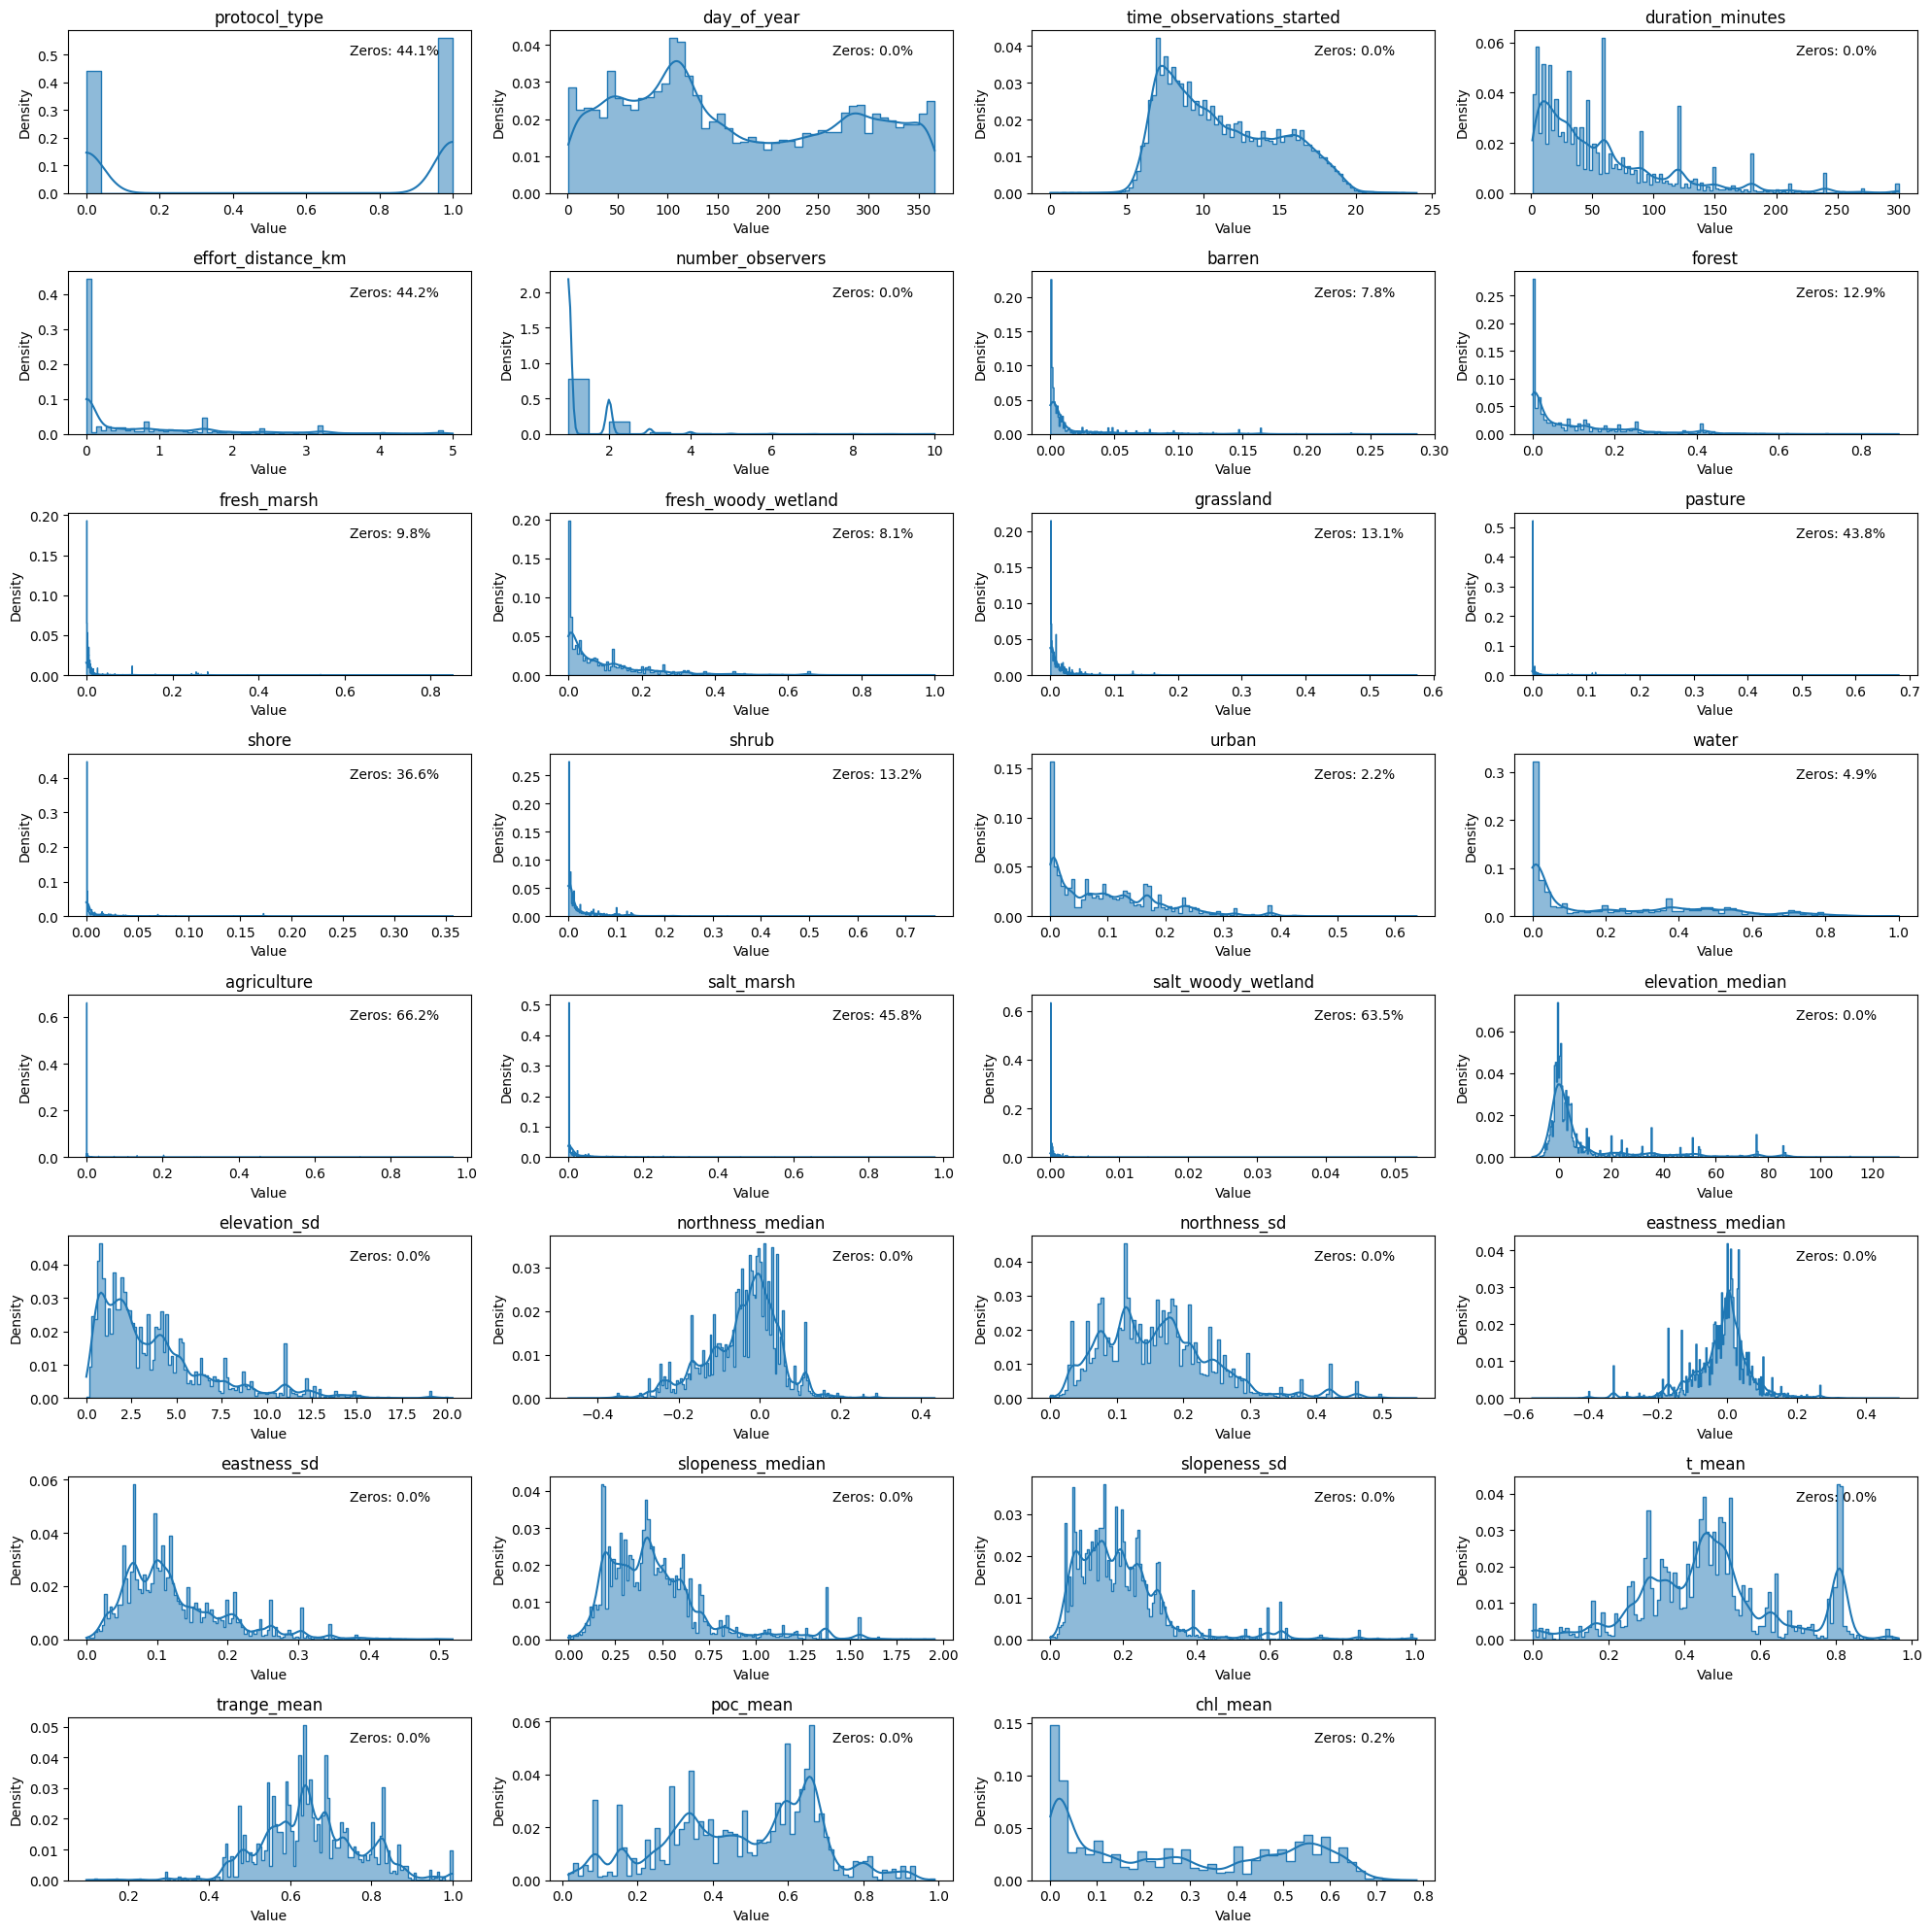

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure for feature histograms
plt.figure(figsize=(20, 20))

# Create a grid of subplots based on the number of features
n_features = feat.shape[1]
rows = (n_features + 3) // 4  # Calculate number of rows needed (4 columns per row)

# Plot histograms for each feature
for i in range(n_features):
    plt.subplot(rows, 4, i+1)
    
    # Get feature data and name
    col_data = feat[:, i]
    col_name = feature_names[i]
    
    # Plot normalized histogram
    sns.histplot(col_data, kde=True, stat='probability', element='step')
    plt.title(f'{col_name}')
    plt.xlabel('Value')
    plt.ylabel('Density')
    
    # Add text with zero/non-zero counts
    zero_pct = feat_summary[col_name]['zero_percentage']
    plt.annotate(f'Zeros: {zero_pct:.1f}%', xy=(0.7, 0.85), xycoords='axes fraction')

plt.tight_layout()
plt.show()

## Label Analysis

Let's analyze the label columns (species counts, columns 34-437 from the original dataset). We'll summarize the zero/non-zero counts and visualize their distributions.

In [15]:
# Analyze all label columns

# Summarize labels
label_summary = {}

for i in range(label.shape[1]):
    col = label[:, i]
    col_name = label_names[i]
    zero_count = np.sum(col == 0)
    non_zero_count = len(col) - zero_count
    
    label_summary[col_name] = {
        'zero_count': zero_count,
        'non_zero_count': non_zero_count,
        'zero_percentage': zero_count / len(col) * 100,
        'min': np.min(col),
        'max': np.max(col),
        'mean': np.mean(col),
        'median': np.median(col)
    }

# Create overall summary for all labels
label_zeros = np.sum(label == 0)
total_elements = label.size
label_non_zeros = total_elements - label_zeros

print(f"Overall Label Statistics:")
print(f"Total elements: {total_elements}")
print(f"Zero elements: {label_zeros} ({label_zeros/total_elements*100:.2f}%)")
print(f"Non-zero elements: {label_non_zeros} ({label_non_zeros/total_elements*100:.2f}%)")

# Convert to DataFrame for better visualization (showing all labels)
label_df = pd.DataFrame(label_summary).T

# Display summary statistics
print("\nLabel Summary Statistics:")
print(f"Number of labels: {len(label_df)}")
print(f"Average zero percentage: {label_df['zero_percentage'].mean():.2f}%")
print(f"Median zero percentage: {label_df['zero_percentage'].median():.2f}%")
print(f"Max zero percentage: {label_df['zero_percentage'].max():.2f}%")
print(f"Min zero percentage: {label_df['zero_percentage'].min():.2f}%")

label_df.to_csv("label_summary.csv", index=True)

Overall Label Statistics:
Total elements: 40436200
Zero elements: 38904038 (96.21%)
Non-zero elements: 1532162 (3.79%)

Label Summary Statistics:
Number of labels: 350
Average zero percentage: 96.21%
Median zero percentage: 99.18%
Max zero percentage: 99.99%
Min zero percentage: 45.63%


## Correlation Analysis

Let's analyze the correlations between features and between labels to identify patterns and relationships in the data.

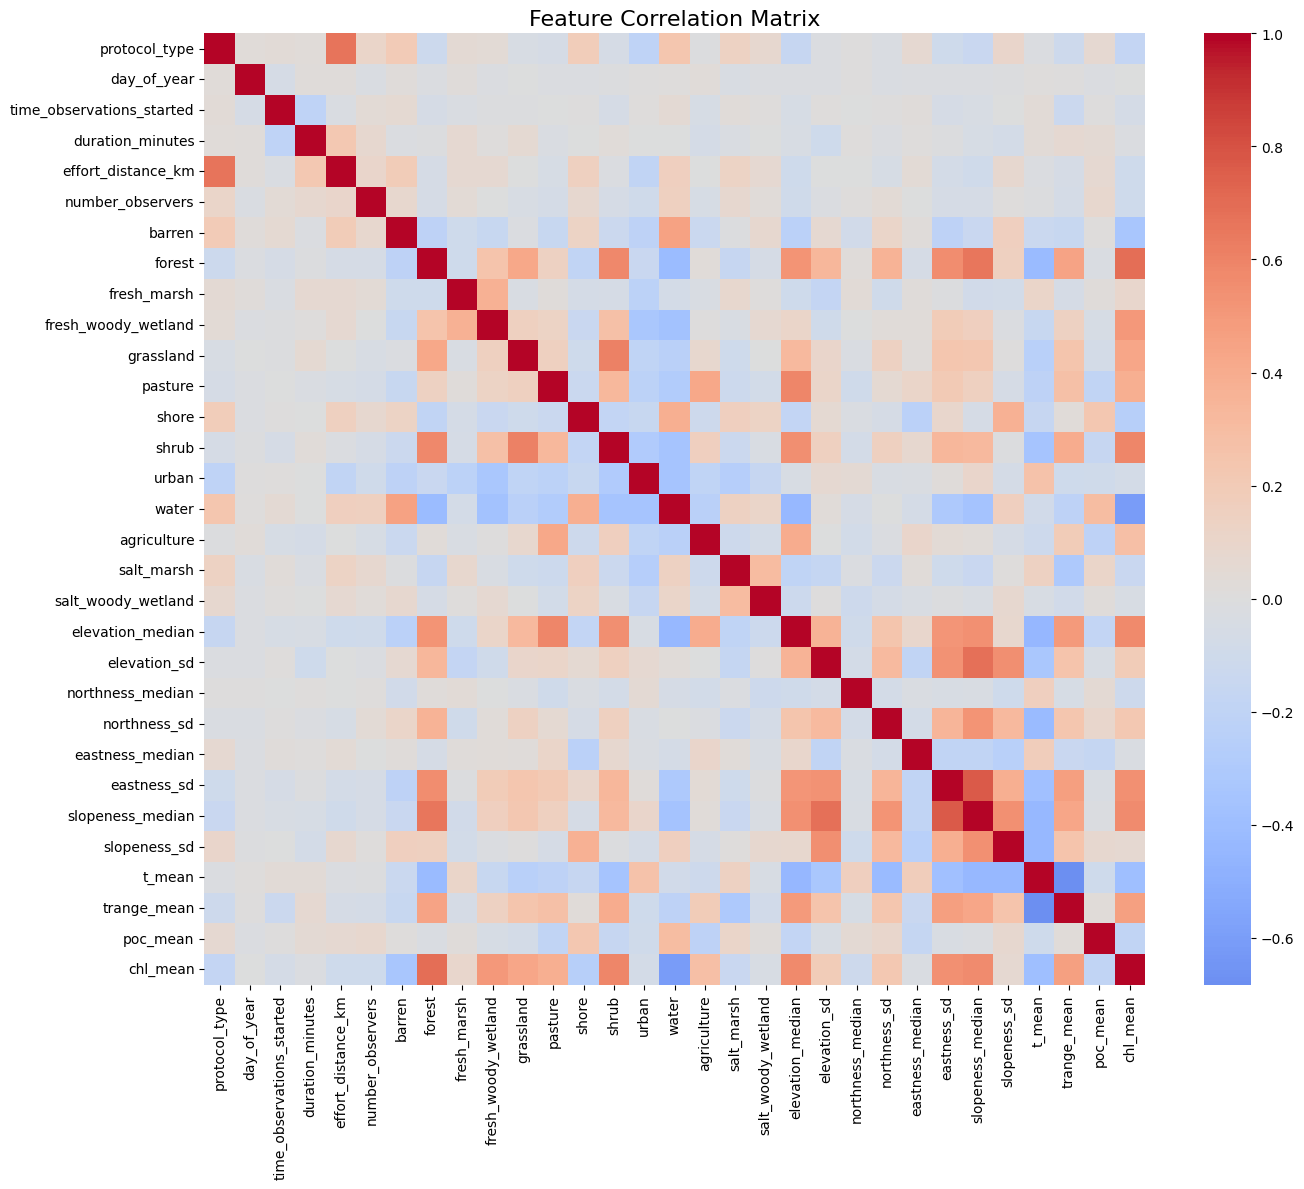

Highly correlated feature pairs (|correlation| > 0.5):
eastness_sd & slopeness_median: 0.764
forest & chl_mean: 0.687
t_mean & trange_mean: -0.683
elevation_sd & slopeness_median: 0.682
protocol_type & effort_distance_km: 0.666
forest & slopeness_median: 0.660
water & chl_mean: -0.608
grassland & shrub: 0.606
pasture & elevation_median: 0.589
shrub & chl_mean: 0.587
forest & shrub: 0.581
elevation_median & chl_mean: 0.569
slopeness_median & chl_mean: 0.560
forest & eastness_sd: 0.559
shrub & elevation_median: 0.550
elevation_sd & slopeness_sd: 0.548
elevation_median & slopeness_median: 0.542
eastness_sd & chl_mean: 0.541
slopeness_median & slopeness_sd: 0.540
elevation_sd & eastness_sd: 0.537
northness_sd & slopeness_median: 0.527
forest & elevation_median: 0.521
elevation_median & eastness_sd: 0.514
fresh_woody_wetland & chl_mean: 0.507


In [16]:
# Feature correlation analysis
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation matrix for features
feat_df = pd.DataFrame(feat, columns=feature_names)
feat_corr = feat_df.corr()

# Plot correlation heatmap for features
plt.figure(figsize=(14, 12))
sns.heatmap(feat_corr, annot=False, cmap='coolwarm', center=0, 
            xticklabels=feat_corr.columns, yticklabels=feat_corr.columns)
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

# Identify highly correlated feature pairs
feat_corr_pairs = []
for i in range(len(feature_names)):
    for j in range(i+1, len(feature_names)):
        if abs(feat_corr.iloc[i, j]) > 0.5:  # Threshold for high correlation
            feat_corr_pairs.append((feature_names[i], feature_names[j], feat_corr.iloc[i, j]))

# Display highly correlated feature pairs
if feat_corr_pairs:
    print("Highly correlated feature pairs (|correlation| > 0.5):")
    for pair in sorted(feat_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"{pair[0]} & {pair[1]}: {pair[2]:.3f}")
else:
    print("No feature pairs with correlation above 0.5 found.")